# Convolutional Neural Networks (CNNs)

CNNs are a class of deep learning models designed to process structured grid data — especially images. Instead of connecting every input pixel to every neuron like a traditional dense network, CNNs use small learnable filters that slide across the input and detect local patterns. Early layers tend to pick up low-level features like edges and corners, while deeper layers combine those into textures, shapes, and eventually whole objects.

They've become the backbone of computer vision: image classification, object detection, image segmentation, medical imaging, and even video analysis. If the data has spatial structure, CNNs are usually the first architecture worth reaching for.

## Key Components

- **Input Layer** — Receives the raw pixel values as a grid (height × width × channels). For a color image that's 3 channels (RGB); for grayscale it's 1.
- **Convolutional Layer** — The core of the architecture. Applies a set of learnable filters to the input, each one producing a feature map that highlights a particular pattern.
- **Activation Layer** — Adds non-linearity after convolution. Without it the whole stack would collapse into a single linear transformation. ReLU is the standard choice.
- **Pooling Layer** — Shrinks the spatial dimensions of each feature map by summarizing small regions. Max pooling keeps the strongest activation in each window, which helps reduce computation and adds a bit of translation invariance.
- **Flattening** — After several rounds of convolution and pooling, the remaining feature maps get stretched into a single 1D vector so they can be fed into dense layers.
- **Fully Connected Layer** — A standard dense layer that learns high-level combinations of the extracted features. Usually comes near the end of the network.
- **Output Layer** — Produces the final prediction. For multi-class classification this is typically a softmax layer; for binary problems, sigmoid; for regression, a linear activation.

## How Convolution Works

A **filter (kernel)** is a small matrix of weights — say 3×3 or 5×5 — that the network learns during training. It slides across the input image one position at a time. At each position it performs **element-wise multiplication** between its own values and the patch of the image it's currently sitting on, then **sums all those products** into a single number. That number gets written into the corresponding cell of the **feature map**, which is the output image produced by that filter.

**Stride** controls how far the filter moves on each step. A stride of 1 moves it one pixel at a time and produces a large output. A stride of 2 skips every other position, cutting the output size roughly in half. **Padding** adds a border of zeros around the input so the filter can visit the edge pixels too. With `SAME` padding the output ends up the same size as the input; with `VALID` padding the output shrinks because the filter can't go past the border.

Compared to fully connected layers, this is dramatically more efficient. A dense layer needs a separate weight for every input–output pair, which blows up for high-resolution images. A convolutional layer uses the **same filter weights everywhere** across the image — a concept called weight sharing — which keeps the parameter count small and makes the learned features inherently position-agnostic.

## Step 1 — Import Libraries

In [1]:
import tensorflow as tf  # Deep learning framework — handles tensors, layers, and GPU acceleration
import matplotlib.pyplot as plt  # Visualization library for displaying images and feature maps

plt.rc('image', cmap='gray')  # Set default colormap to grayscale so all images render in gray tones
plt.rc('figure', autolayout=True)  # Automatically tighten subplot layouts to prevent overlapping labels

## Step 2 — Load and Preprocess the Image

> **Note:** Replace `image_path` with the path to your own image file (`.jpg`, `.png`, etc. all work). If the file isn't found, the notebook will generate a synthetic gradient image automatically so you can still follow along without interruption.

Original image shape: (300, 300, 1)


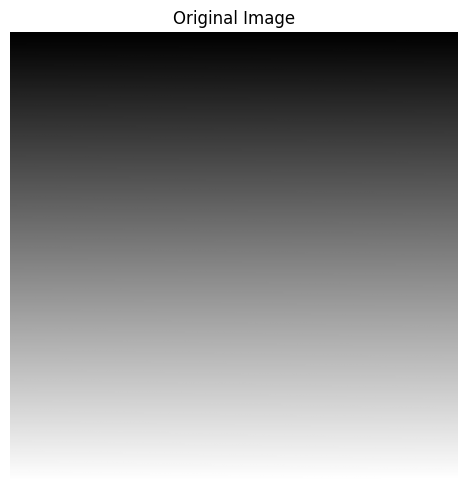

In [2]:
import numpy as np  # Used here only to generate a fallback image if no file path is provided

image_path = "your_image.jpg"  # Replace this with the actual path to your image

try:
    raw = tf.io.read_file(image_path)  # Read the raw bytes of the image from disk
    image = tf.image.decode_image(raw, channels=1)  # Decode as grayscale — forces a single channel
    image = tf.image.resize(image, [300, 300])  # Resize to a uniform 300×300 for consistent processing
except Exception:
    # No image found — generate a synthetic gradient pattern for demonstration
    gradient = np.linspace(0, 255, 300 * 300, dtype=np.float32).reshape(300, 300, 1)  # Smooth gradient array
    image = tf.constant(gradient)  # Wrap in a TensorFlow constant so it behaves like a real image tensor

image = tf.cast(image, tf.float32)  # Convert pixel values to float32 — required for convolution operations
print("Original image shape:", image.shape)  # Should print (300, 300, 1)

plt.figure(figsize=(5, 5))  # Create a 5×5 inch figure
plt.title("Original Image")  # Add a descriptive title above the plot
plt.axis("off")  # Turn off axis ticks and labels — cleaner for image display
plt.imshow(tf.squeeze(image))  # Drop the channel dimension so imshow gets a 2D array
plt.show()  # Render the figure

image = tf.expand_dims(image, axis=0)  # Add a batch dimension at axis 0 → shape becomes (1, 300, 300, 1)

## Step 3 — Define Convolution Kernel

This is a **Laplacian edge detection filter**. The high center weight surrounded by negative weights means it fires strongly wherever there's a sharp change in pixel intensity — which typically corresponds to edges or boundaries in the image.

In [3]:
kernel = tf.constant([  # Define the 3×3 Laplacian kernel weights as a TensorFlow constant
    [-1, -1, -1],       # Top row: negative weights penalize surrounding pixels
    [-1,  8, -1],       # Middle row: strong positive center amplifies the focal pixel
    [-1, -1, -1]        # Bottom row: same as top — symmetric filter
], dtype=tf.float32)    # Use float32 to match the image tensor's dtype

kernel = tf.reshape(kernel, [3, 3, 1, 1])  # Reshape to [filter_h, filter_w, in_channels, out_channels] as required by conv2d

## Step 4 — Apply Convolution Layer

Conv output shape: (1, 300, 300, 1)


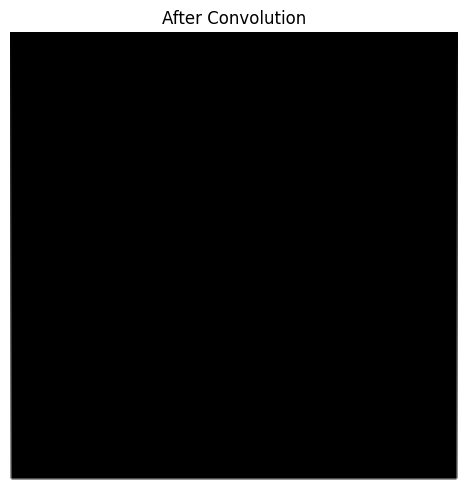

In [4]:
conv_output = tf.nn.conv2d(  # Run 2D convolution over the input image
    image,                   # Input tensor — shape (1, 300, 300, 1) with the batch dim
    kernel,                  # The Laplacian filter defined in the previous step
    strides=1,               # Slide the filter one pixel at a time in both directions
    padding='SAME'           # Zero-pad the borders so the output matches the input spatial size
)

print("Conv output shape:", conv_output.shape)  # Expected: (1, 300, 300, 1)

plt.figure(figsize=(5, 5))  # Set figure to 5×5 inches
plt.title("After Convolution")  # Label the plot
plt.axis("off")  # Hide axis decorations
plt.imshow(tf.squeeze(conv_output))  # Squeeze out batch and channel dims for display
plt.show()  # Render the figure

## Step 5 — Apply ReLU Activation

ReLU output shape: (1, 300, 300, 1)


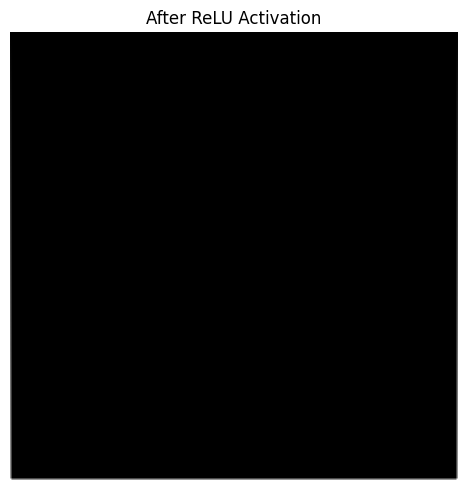

In [5]:
relu_output = tf.nn.relu(conv_output)  # Apply ReLU — any value below zero gets clipped to zero

print("ReLU output shape:", relu_output.shape)  # Shape should still be (1, 300, 300, 1)

plt.figure(figsize=(5, 5))  # Set figure size
plt.title("After ReLU Activation")  # Descriptive title
plt.axis("off")  # Clean display without axis ticks
plt.imshow(tf.squeeze(relu_output))  # Squeeze to 2D before passing to imshow
plt.show()  # Render the figure

## Step 6 — Apply Max Pooling

Max pool output shape: (1, 150, 150, 1)


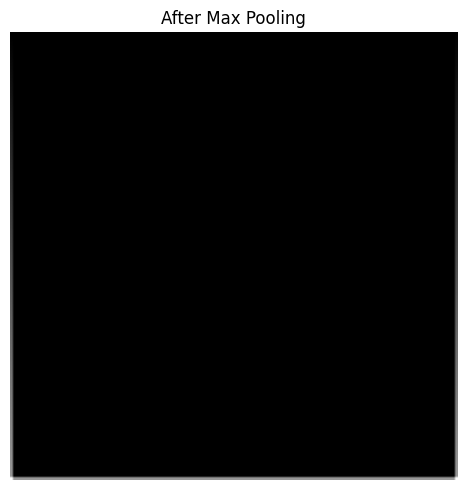

In [6]:
pool_output = tf.nn.max_pool2d(  # Apply 2D max pooling to downsample the feature map
    relu_output,                 # Input: the ReLU-activated feature map
    ksize=2,                     # Pool over 2×2 pixel windows
    strides=2,                   # Move the window 2 pixels at a time — no overlap, halves the dimensions
    padding='SAME'               # Add padding if needed to ensure the window covers the full input
)

print("Max pool output shape:", pool_output.shape)  # Expected: (1, 150, 150, 1)

plt.figure(figsize=(5, 5))  # Set figure size
plt.title("After Max Pooling")  # Label the visualization
plt.axis("off")  # Hide axis ticks for a cleaner look
plt.imshow(tf.squeeze(pool_output))  # Squeeze batch and channel dims before displaying
plt.show()  # Render the figure

## Step 7 — Flatten the Feature Maps

In [7]:
flatten_layer = tf.keras.layers.Flatten()  # Instantiate a Flatten layer to collapse spatial dims into a vector
flat_output = flatten_layer(pool_output)   # Pass the pooled feature map through — output is 1D per sample

print("Flattened output shape:", flat_output.shape)  # Expected: (1, 22500) — 150*150*1
print("First 20 flattened values:", flat_output.numpy()[0][:20])  # Peek at the first 20 values in the vector

Flattened output shape: (1, 22500)
First 20 flattened values: [2.5415282 0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.       ]


## Step 8 — Fully Connected Layer

In [8]:
dense_layer = tf.keras.layers.Dense(units=64, activation='relu')  # Dense layer with 64 neurons and ReLU activation
dense_output = dense_layer(flat_output)                           # Forward pass — maps the 22500-dim vector to 64 values

print("Dense output shape:", dense_output.shape)  # Expected: (1, 64)

Dense output shape: (1, 64)


## Advantages & Limitations

**Advantages:**
- **Automatically learns features** — no need to hand-craft filters or descriptors; the network figures out what to look for during training.
- **Effective at spatial pattern detection** — the convolutional structure is purpose-built for capturing local relationships in grid data like images.
- **Robust to translation, rotation, and scaling** — shared filter weights mean a learned feature gets recognized regardless of where it appears in the image.
- **Handles large datasets well** — performance tends to improve predictably as more labeled data is added, which makes CNNs a good fit for large-scale vision tasks.
- **Supports end-to-end training** — the full pipeline from raw pixels to final predictions can be optimized jointly with backpropagation.

**Limitations:**
- **Computationally intensive** — deep CNNs are expensive to train and often require dedicated GPUs or TPUs.
- **Prone to overfitting with limited data** — without enough training examples, the model may memorize the training set instead of learning generalizable patterns.
- **Requires large labeled datasets** — unlike some semi-supervised or self-supervised approaches, standard supervised CNNs depend heavily on annotation volume.
- **Limited interpretability** — understanding exactly what a CNN has learned internally is still an open research problem.
- **Sensitive to adversarial examples** — carefully crafted perturbations that are invisible to humans can reliably fool a CNN into misclassifying an image.